In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**EXPERIMENT ONE**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communication overhead for round 1: 0.2156 MB
Global model accuracy after round 1: 0.5199
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communication overhead for round 2: 0.2156 MB
Global model accuracy after round 2: 0.6142
Round 3/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communication overhead for round 3: 0.2156 MB
Global model accuracy after round 3: 0.6719
Round 4/30
Training on client 1
Training on client 2
Training on

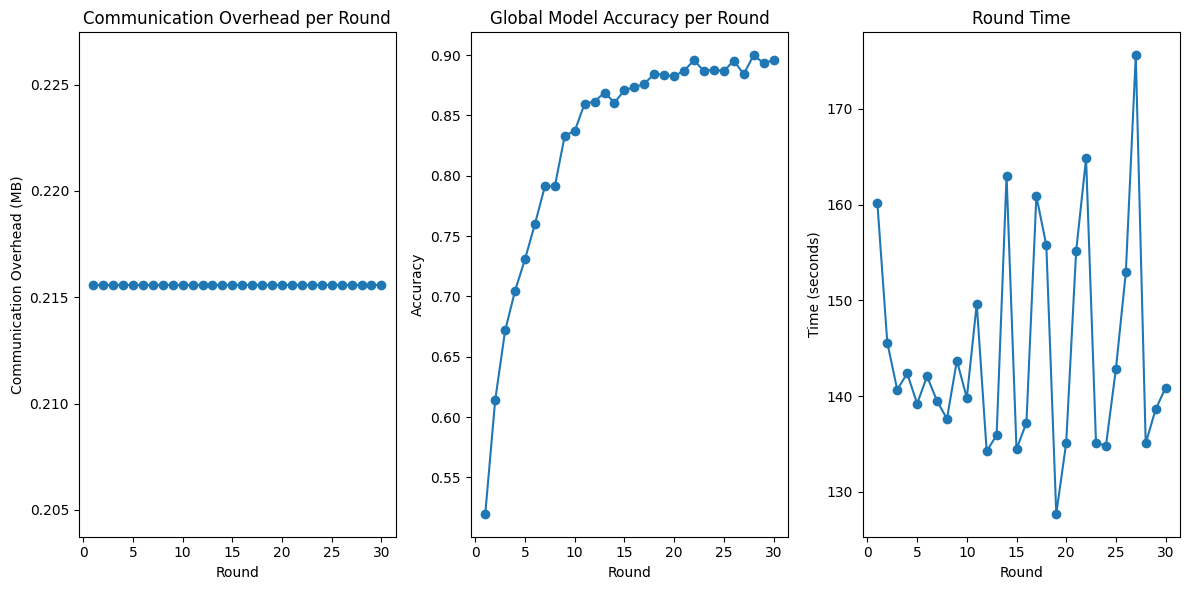

In [ ]:
# Define the global RNN model
def create_rnn_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, input_shape=(128, 9), return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=10):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=10)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 10
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
global_model = create_rnn_model(num_classes)
global_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(x_test, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT TWO**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Communication overhead for round 1: 0.2156 MB
Global model accuracy after round 1: 0.4662
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Communication overhead for

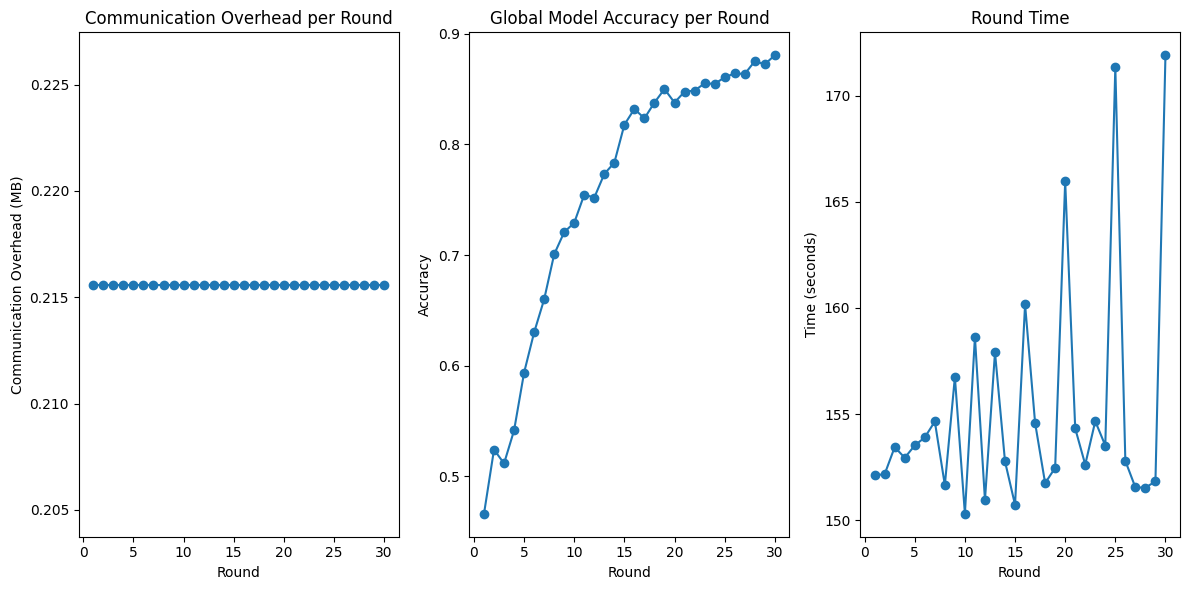

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
import time
import matplotlib.pyplot as plt

# Load and preprocess the UCI HAR dataset
def load_and_preprocess_data():
    # Load the dataset
    def load_file(filepath):
        return np.loadtxt(filepath)

    def load_group(filenames, prefix=''):
        loaded = [load_file(prefix + name) for name in filenames]
        return np.dstack(loaded)

    def load_dataset_group(group, prefix=''):
        filepath = prefix + group + '/Inertial Signals/'
        filenames = ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt',
                     'body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt',
                     'body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
        X = load_group(filenames, filepath)
        y = load_file(prefix + group + '/y_'+group+'.txt')
        return X, y

    # Load train and test dataset
    X_train, y_train = load_dataset_group('train', '/content/drive/MyDrive/UCI HAR Dataset/')
    X_test, y_test = load_dataset_group('test', '/content/drive/MyDrive/UCI HAR Dataset/')

    # One-hot encode labels
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

    return (X_train, y_train), (X_test, y_test), y_train.shape[1]

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, input_shape=(128, 9), return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=20):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=20)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 20
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
global_model = create_rnn_model(num_classes)
global_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(x_test, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT THREE**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Communication overhead for round 1: 0.2156 MB
Global model accuracy after round 1: 0.4720
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Trai

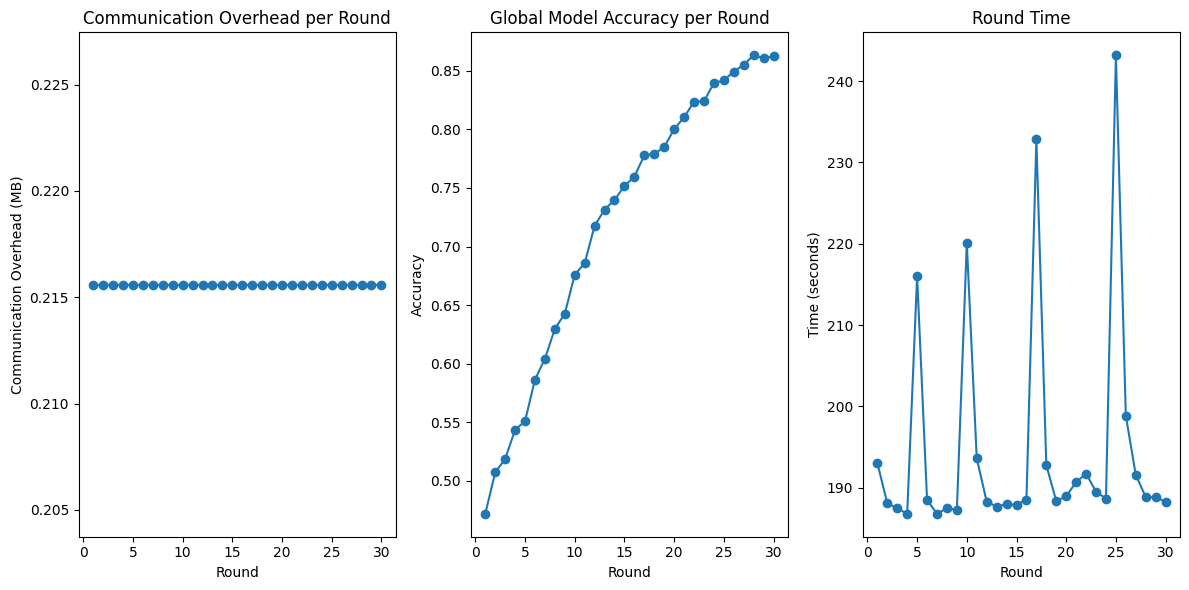

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
import time

# Load and preprocess the UCI HAR dataset
def load_and_preprocess_data():
    # Load the dataset
    def load_file(filepath):
        return np.loadtxt(filepath)

    def load_group(filenames, prefix=''):
        loaded = [load_file(prefix + name) for name in filenames]
        return np.dstack(loaded)

    def load_dataset_group(group, prefix=''):
        filepath = prefix + group + '/Inertial Signals/'
        filenames = ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt',
                     'body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt',
                     'body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
        X = load_group(filenames, filepath)
        y = load_file(prefix + group + '/y_'+group+'.txt')
        return X, y

    # Load train and test dataset
    X_train, y_train = load_dataset_group('train', '/content/drive/MyDrive/UCI HAR Dataset/')
    X_test, y_test = load_dataset_group('test', '/content/drive/MyDrive/UCI HAR Dataset/')

    # One-hot encode labels
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

    return (X_train, y_train), (X_test, y_test), y_train.shape[1]

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()
# Define the global RNN model
def create_rnn_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, input_shape=(128, 9), return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=30):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=30)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 30
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
global_model = create_rnn_model(num_classes)
global_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(x_test, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT FOUR**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Communication overhead for round 1: 0.2156 MB
Global model accuracy after round 1: 0.3940
Round 2/30
Training on clien

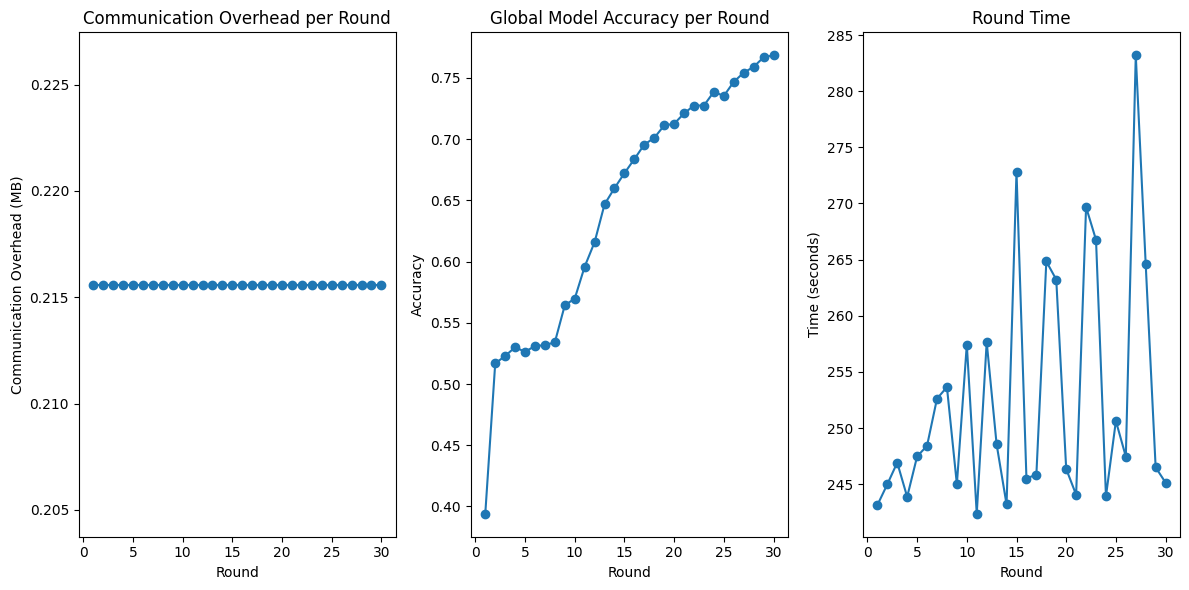

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
import time
import matplotlib.pyplot as plt

# Load and preprocess the UCI HAR dataset
def load_and_preprocess_data():
    # Load the dataset
    def load_file(filepath):
        return np.loadtxt(filepath)

    def load_group(filenames, prefix=''):
        loaded = [load_file(prefix + name) for name in filenames]
        return np.dstack(loaded)

    def load_dataset_group(group, prefix=''):
        filepath = prefix + group + '/Inertial Signals/'
        filenames = ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt',
                     'body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt',
                     'body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
        X = load_group(filenames, filepath)
        y = load_file(prefix + group + '/y_'+group+'.txt')
        return X, y

    # Load train and test dataset
    X_train, y_train = load_dataset_group('train', '/content/drive/MyDrive/UCI HAR Dataset/')
    X_test, y_test = load_dataset_group('test', '/content/drive/MyDrive/UCI HAR Dataset/')

    # One-hot encode labels
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

    return (X_train, y_train), (X_test, y_test), y_train.shape[1]

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()
# Define the global RNN model
def create_rnn_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, input_shape=(128, 9), return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=40):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=40)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 40
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
global_model = create_rnn_model(num_classes)
global_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(x_test, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT FIVE**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training

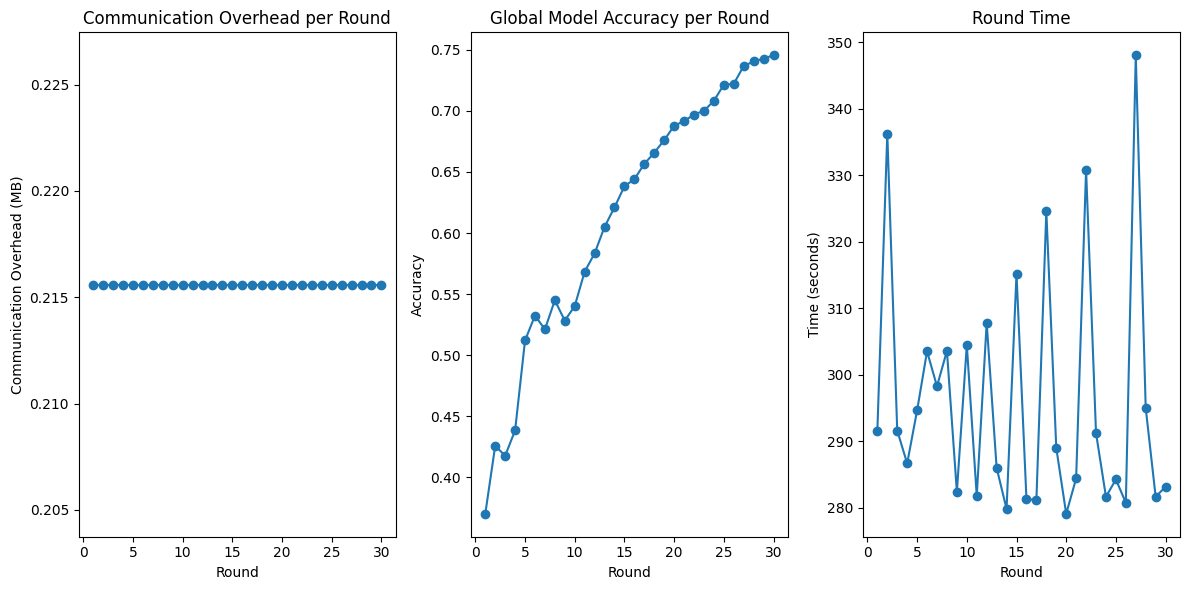

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
import time
import matplotlib.pyplot as plt

# Load and preprocess the UCI HAR dataset
def load_and_preprocess_data():
    # Load the dataset
    def load_file(filepath):
        return np.loadtxt(filepath)

    def load_group(filenames, prefix=''):
        loaded = [load_file(prefix + name) for name in filenames]
        return np.dstack(loaded)

    def load_dataset_group(group, prefix=''):
        filepath = prefix + group + '/Inertial Signals/'
        filenames = ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt',
                     'body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt',
                     'body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
        X = load_group(filenames, filepath)
        y = load_file(prefix + group + '/y_'+group+'.txt')
        return X, y

    # Load train and test dataset
    X_train, y_train = load_dataset_group('train', '/content/drive/MyDrive/UCI HAR Dataset/')
    X_test, y_test = load_dataset_group('test', '/content/drive/MyDrive/UCI HAR Dataset/')

    # One-hot encode labels
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

    return (X_train, y_train), (X_test, y_test), y_train.shape[1]

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()
# Define the global RNN model
def create_rnn_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, input_shape=(128, 9), return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=50):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=50)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 50
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
global_model = create_rnn_model(num_classes)
global_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(x_test, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT SIX**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training

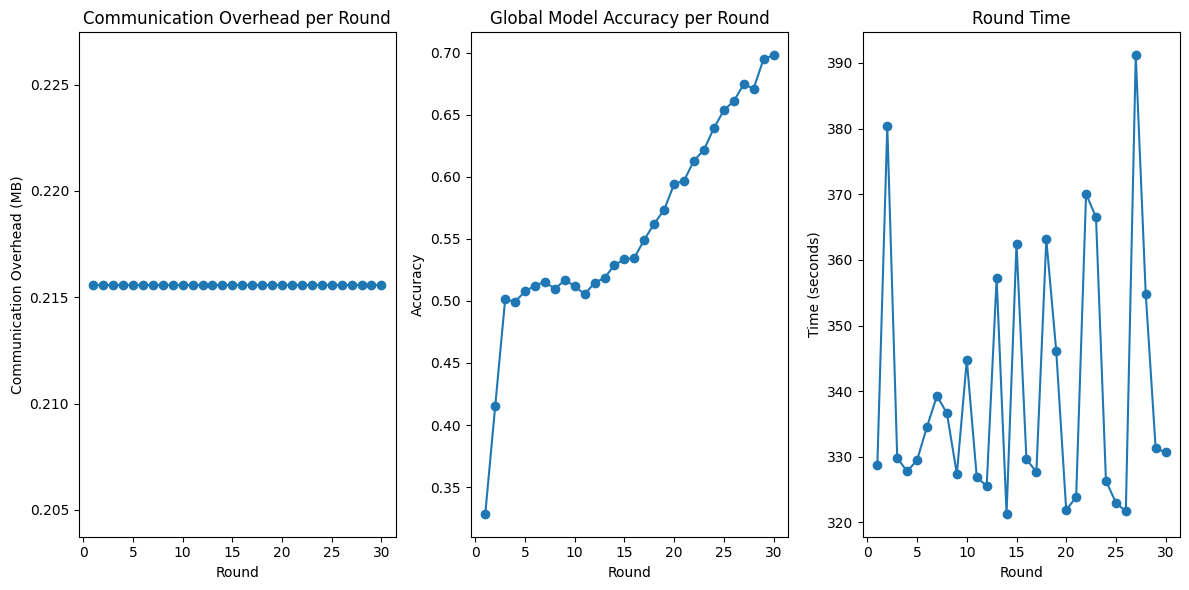

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
import time
import matplotlib.pyplot as plt

# Load and preprocess the UCI HAR dataset
def load_and_preprocess_data():
    # Load the dataset
    def load_file(filepath):
        return np.loadtxt(filepath)

    def load_group(filenames, prefix=''):
        loaded = [load_file(prefix + name) for name in filenames]
        return np.dstack(loaded)

    def load_dataset_group(group, prefix=''):
        filepath = prefix + group + '/Inertial Signals/'
        filenames = ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt',
                     'body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt',
                     'body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
        X = load_group(filenames, filepath)
        y = load_file(prefix + group + '/y_'+group+'.txt')
        return X, y

    # Load train and test dataset
    X_train, y_train = load_dataset_group('train', '/content/drive/MyDrive/UCI HAR Dataset/')
    X_test, y_test = load_dataset_group('test', '/content/drive/MyDrive/UCI HAR Dataset/')

    # One-hot encode labels
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

    return (X_train, y_train), (X_test, y_test), y_train.shape[1]

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()
# Define the global RNN model
def create_rnn_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, input_shape=(128, 9), return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=60):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=60)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 60
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
global_model = create_rnn_model(num_classes)
global_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(x_test, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT SEVEN**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training

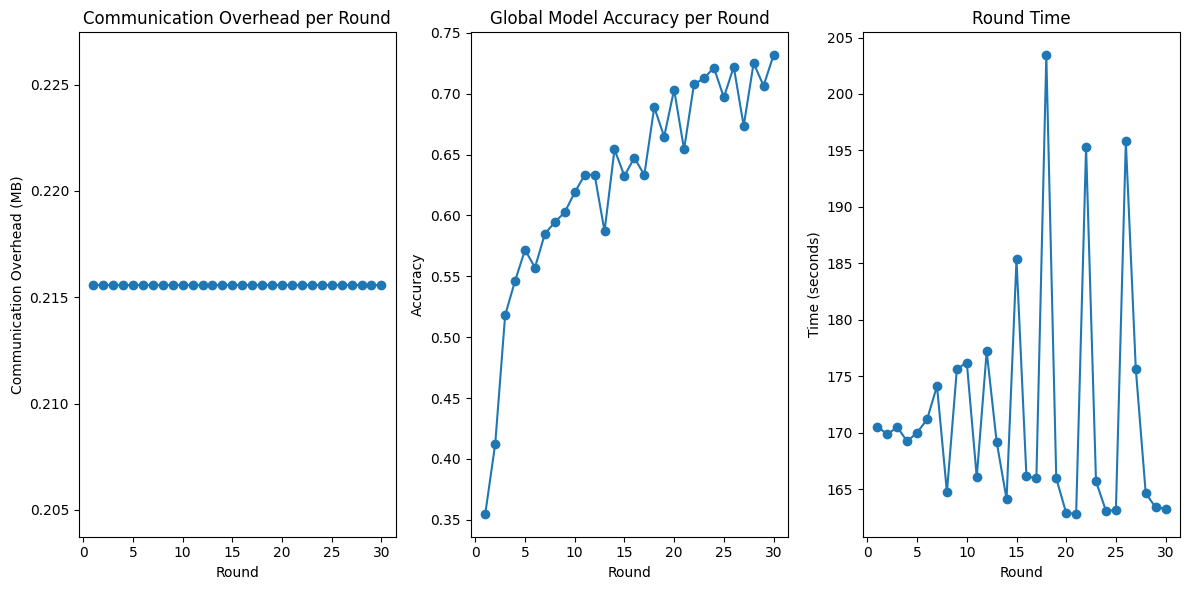

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
import time
import matplotlib.pyplot as plt

# Load and preprocess the UCI HAR dataset
def load_and_preprocess_data():
    # Load the dataset
    def load_file(filepath):
        return np.loadtxt(filepath)

    def load_group(filenames, prefix=''):
        loaded = [load_file(prefix + name) for name in filenames]
        return np.dstack(loaded)

    def load_dataset_group(group, prefix=''):
        filepath = prefix + group + '/Inertial Signals/'
        filenames = ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt',
                     'body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt',
                     'body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
        X = load_group(filenames, filepath)
        y = load_file(prefix + group + '/y_'+group+'.txt')
        return X, y

    # Load train and test dataset
    X_train, y_train = load_dataset_group('train', '/content/drive/MyDrive/UCI HAR Dataset/')
    X_test, y_test = load_dataset_group('test', '/content/drive/MyDrive/UCI HAR Dataset/')

    # One-hot encode labels
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

    return (X_train, y_train), (X_test, y_test), y_train.shape[1]

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()
# Define the global RNN model
def create_rnn_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, input_shape=(128, 9), return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=70):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=70)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 70
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
global_model = create_rnn_model(num_classes)
global_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(x_test, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT EIGHT**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training

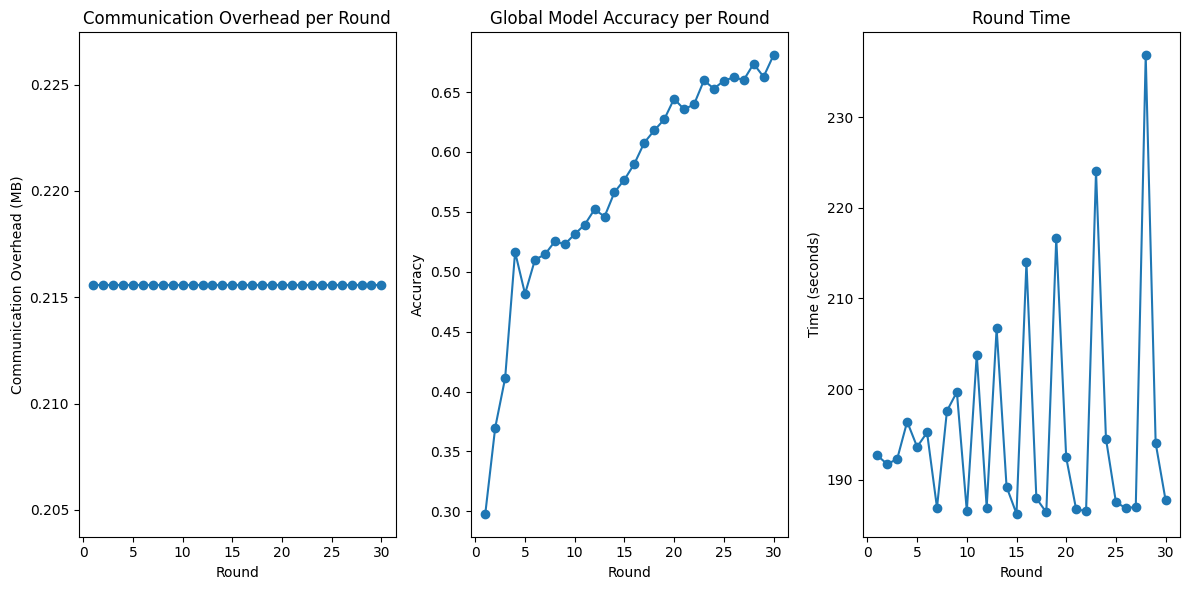

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
import time
import matplotlib.pyplot as plt

# Load and preprocess the UCI HAR dataset
def load_and_preprocess_data():
    # Load the dataset
    def load_file(filepath):
        return np.loadtxt(filepath)

    def load_group(filenames, prefix=''):
        loaded = [load_file(prefix + name) for name in filenames]
        return np.dstack(loaded)

    def load_dataset_group(group, prefix=''):
        filepath = prefix + group + '/Inertial Signals/'
        filenames = ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt',
                     'body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt',
                     'body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
        X = load_group(filenames, filepath)
        y = load_file(prefix + group + '/y_'+group+'.txt')
        return X, y

    # Load train and test dataset
    X_train, y_train = load_dataset_group('train', '/content/drive/MyDrive/UCI HAR Dataset/')
    X_test, y_test = load_dataset_group('test', '/content/drive/MyDrive/UCI HAR Dataset/')

    # One-hot encode labels
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

    return (X_train, y_train), (X_test, y_test), y_train.shape[1]

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()
# Define the global RNN model
def create_rnn_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, input_shape=(128, 9), return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=80):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=80)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 80
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
global_model = create_rnn_model(num_classes)
global_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(x_test, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT NINE**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training

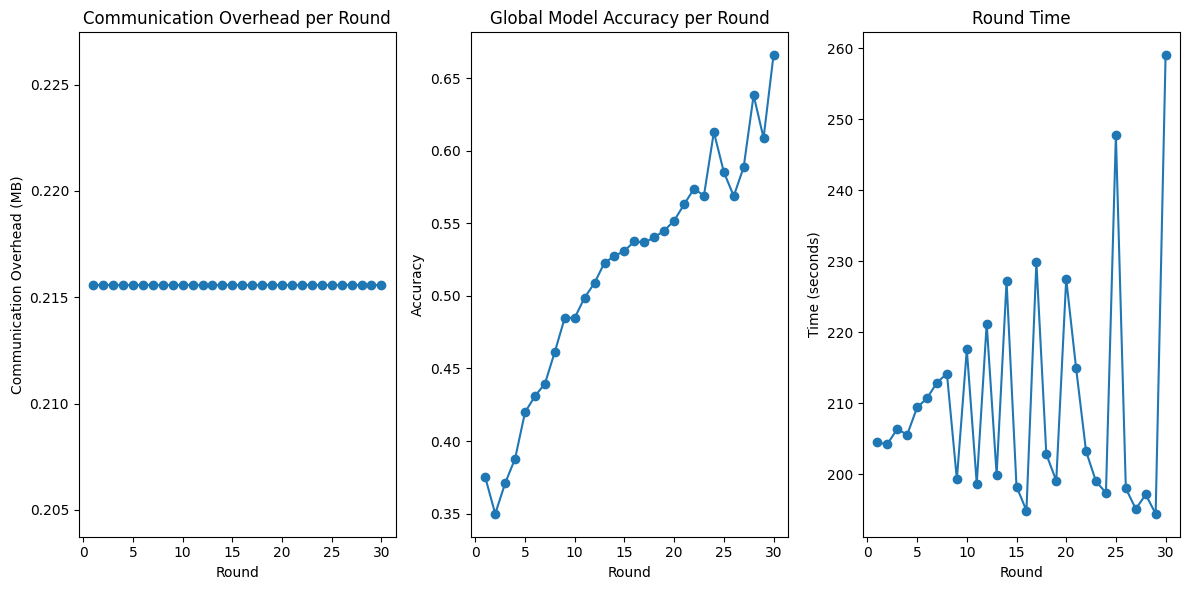

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
import time
import matplotlib.pyplot as plt

# Load and preprocess the UCI HAR dataset
def load_and_preprocess_data():
    # Load the dataset
    def load_file(filepath):
        return np.loadtxt(filepath)

    def load_group(filenames, prefix=''):
        loaded = [load_file(prefix + name) for name in filenames]
        return np.dstack(loaded)

    def load_dataset_group(group, prefix=''):
        filepath = prefix + group + '/Inertial Signals/'
        filenames = ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt',
                     'body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt',
                     'body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
        X = load_group(filenames, filepath)
        y = load_file(prefix + group + '/y_'+group+'.txt')
        return X, y

    # Load train and test dataset
    X_train, y_train = load_dataset_group('train', '/content/drive/MyDrive/UCI HAR Dataset/')
    X_test, y_test = load_dataset_group('test', '/content/drive/MyDrive/UCI HAR Dataset/')

    # One-hot encode labels
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

    return (X_train, y_train), (X_test, y_test), y_train.shape[1]

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()
# Define the global RNN model
def create_rnn_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, input_shape=(128, 9), return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=90):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=90)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 90
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
global_model = create_rnn_model(num_classes)
global_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(x_test, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT TEN**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training

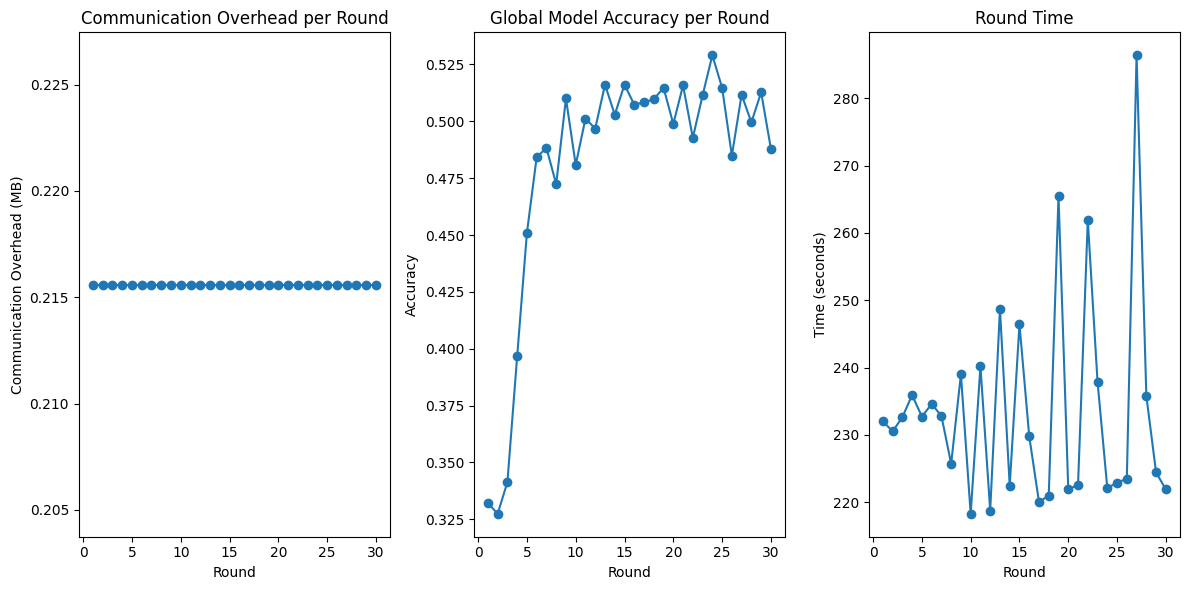

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
import time
import matplotlib.pyplot as plt

# Load and preprocess the UCI HAR dataset
def load_and_preprocess_data():
    # Load the dataset
    def load_file(filepath):
        return np.loadtxt(filepath)

    def load_group(filenames, prefix=''):
        loaded = [load_file(prefix + name) for name in filenames]
        return np.dstack(loaded)

    def load_dataset_group(group, prefix=''):
        filepath = prefix + group + '/Inertial Signals/'
        filenames = ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt',
                     'body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt',
                     'body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
        X = load_group(filenames, filepath)
        y = load_file(prefix + group + '/y_'+group+'.txt')
        return X, y

    # Load train and test dataset
    X_train, y_train = load_dataset_group('train', '/content/drive/MyDrive/UCI HAR Dataset/')
    X_test, y_test = load_dataset_group('test', '/content/drive/MyDrive/UCI HAR Dataset/')

    # One-hot encode labels
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

    return (X_train, y_train), (X_test, y_test), y_train.shape[1]

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()
# Define the global RNN model
def create_rnn_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, input_shape=(128, 9), return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=100):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=100)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 100
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
global_model = create_rnn_model(num_classes)
global_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(x_test, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**CENTRALIZED EXPERIMENT**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5250 - loss: 1.1835 - val_accuracy: 0.7730 - val_loss: 0.6651
Epoch 2/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8231 - loss: 0.4622 - val_accuracy: 0.8239 - val_loss: 0.5617
Epoch 3/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8846 - loss: 0.3554 - val_accuracy: 0.8561 - val_loss: 0.5161
Epoch 4/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9269 - loss: 0.1885 - val_accuracy: 0.8744 - val_loss: 0.4759
Epoch 5/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9224 - loss: 0.1912 - val_accuracy: 0.8633 - val_loss: 0.5780
Epoch 6/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9408 - loss: 0.1487 - val_accuracy: 0.8785 - val_loss: 0.5376
Epoch 7/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9535 - loss: 0.1355 - val_accuracy: 0.8873 - val_loss: 0.3804
Epoch 8/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9485 - loss: 0.1312 - val_accu

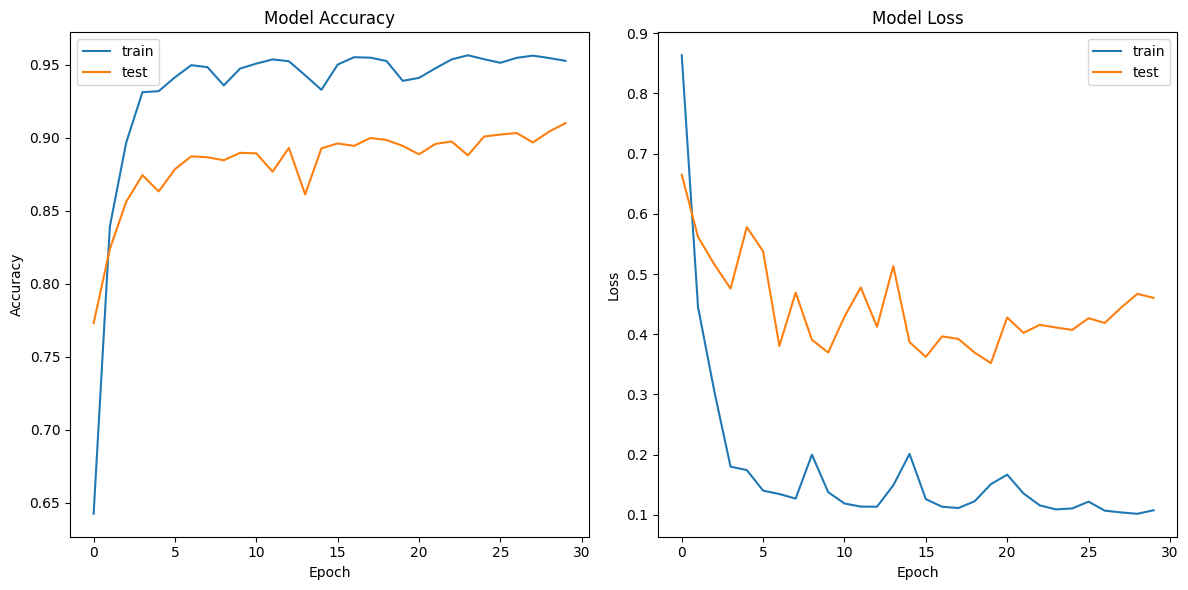

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
import time
import matplotlib.pyplot as plt

# Load and preprocess the UCI HAR dataset
def load_and_preprocess_data():
    # Load the dataset
    def load_file(filepath):
        return np.loadtxt(filepath)

    def load_group(filenames, prefix=''):
        loaded = [load_file(prefix + name) for name in filenames]
        return np.dstack(loaded)

    def load_dataset_group(group, prefix=''):
        filepath = prefix + group + '/Inertial Signals/'
        filenames = ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt',
                     'body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt',
                     'body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
        X = load_group(filenames, filepath)
        y = load_file(prefix + group + '/y_'+group+'.txt')
        return X, y

    # Load train and test dataset
    X_train, y_train = load_dataset_group('train', '/content/drive/MyDrive/UCI HAR Dataset/')
    X_test, y_test = load_dataset_group('test', '/content/drive/MyDrive/UCI HAR Dataset/')

    # One-hot encode labels
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

    return (X_train, y_train), (X_test, y_test), y_train.shape[1]

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, input_shape=(128, 9), return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create and compile the model
model = create_rnn_model(num_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
start_time = time.time()
history = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test), verbose=1)
training_time = time.time() - start_time

# Evaluate the model
final_loss, final_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Final model accuracy: {final_accuracy:.4f}")
print(f"Training time: {training_time:.2f} seconds")

# Visualization
plt.figure(figsize=(12, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()